### Conda Environment Check

In [1]:
from __future__ import print_function
from packaging.version import parse as Version
from platform import python_version

OK = '\x1b[42m[ OK ]\x1b[0m'
FAIL = "\x1b[41m[FAIL]\x1b[0m"

try:
    import importlib
except ImportError:
    print(FAIL, "Python version 3.12.10 is required,"
                " but %s is installed." % sys.version)

def import_version(pkg, min_ver, fail_msg=""):
    mod = None
    try:
        mod = importlib.import_module(pkg)
        if pkg in {'PIL'}:
            ver = mod.VERSION
        else:
            ver = mod.__version__
        if Version(ver) == Version(min_ver):
            print(OK, "%s version %s is installed."
                  % (lib, min_ver))
        else:
            print(FAIL, "%s version %s is required, but %s installed."
                  % (lib, min_ver, ver))    
    except ImportError:
        print(FAIL, '%s not installed. %s' % (pkg, fail_msg))
    return mod


# first check the python version
pyversion = Version(python_version())

if pyversion >= Version("3.12.10"):
    print(OK, "Python version is %s" % pyversion)
elif pyversion < Version("3.12.10"):
    print(FAIL, "Python version 3.12.10 is required,"
                " but %s is installed." % pyversion)
else:
    print(FAIL, "Unknown Python version: %s" % pyversion)

    
print()
requirements = {'numpy': "2.2.5", 'matplotlib': "3.10.1",'sklearn': "1.6.1", 
                'pandas': "2.2.3",'xgboost': "3.0.0", 'shap': "0.47.2", 
                'polars': "1.27.1", 'seaborn': "0.13.2"}

# now the dependencies
for lib, required_version in list(requirements.items()):
    import_version(lib, required_version)

[ OK ] Python version is 3.12.10

[ OK ] numpy version 2.2.5 is installed.
[ OK ] matplotlib version 3.10.1 is installed.
[ OK ] sklearn version 1.6.1 is installed.
[ OK ] pandas version 2.2.3 is installed.
[ OK ] xgboost version 3.0.0 is installed.
[ OK ] shap version 0.47.2 is installed.
[ OK ] polars version 1.27.1 is installed.
[ OK ] seaborn version 0.13.2 is installed.


### First View of Application Dataset

In [6]:
import pandas as pd
import matplotlib
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
pd.set_option('display.max_rows', 150)

# read in the dataset
df_application = pd.read_csv('../data/application_data.csv')

# First view of the dataset
print("Example of the application_data dataset:")
print(df_application.head())
print("\n Shape of the application_data dataset:")
print(df_application.shape)

Example of the application_data dataset:
   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  \
0      100002       1         Cash loans           M            N               Y             0          202500.0   
1      100003       0         Cash loans           F            N               N             0          270000.0   
2      100004       0    Revolving loans           M            Y               Y             0           67500.0   
3      100006       0         Cash loans           F            N               Y             0          135000.0   
4      100007       0         Cash loans           M            N               Y             0          121500.0   

   AMT_CREDIT  AMT_ANNUITY  AMT_GOODS_PRICE NAME_TYPE_SUITE NAME_INCOME_TYPE            NAME_EDUCATION_TYPE  \
0    406597.5      24700.5         351000.0   Unaccompanied          Working  Secondary / secondary special   
1   1293502.5      35698.5        

##### Columns in Application Dataset

In [4]:
print("Basic Information of the application_data dataset:")
print(df_application.info())
print("\n\nColumn Names:")
print(df_application.columns.tolist())

Basic Information of the application_data dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB
None


Column Names:
['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REG

In [3]:
print("\n Description of the application_data dataset:")
print(df_application.describe())


 Description of the application_data dataset:
          SK_ID_CURR         TARGET   CNT_CHILDREN  AMT_INCOME_TOTAL    AMT_CREDIT    AMT_ANNUITY  AMT_GOODS_PRICE  \
count  307511.000000  307511.000000  307511.000000      3.075110e+05  3.075110e+05  307499.000000     3.072330e+05   
mean   278180.518577       0.080729       0.417052      1.687979e+05  5.990260e+05   27108.573909     5.383962e+05   
std    102790.175348       0.272419       0.722121      2.371231e+05  4.024908e+05   14493.737315     3.694465e+05   
min    100002.000000       0.000000       0.000000      2.565000e+04  4.500000e+04    1615.500000     4.050000e+04   
25%    189145.500000       0.000000       0.000000      1.125000e+05  2.700000e+05   16524.000000     2.385000e+05   
50%    278202.000000       0.000000       0.000000      1.471500e+05  5.135310e+05   24903.000000     4.500000e+05   
75%    367142.500000       0.000000       1.000000      2.025000e+05  8.086500e+05   34596.000000     6.795000e+05   
max    45

### Missing Values

In [7]:
print("Percentage of Missing:")
missing_percentage = (df_application.isnull().sum() / len(df_application) * 100).sort_values(ascending=False)
print(missing_percentage[missing_percentage > 0])

Percentage of Missing:
COMMONAREA_AVG                  69.872297
COMMONAREA_MODE                 69.872297
COMMONAREA_MEDI                 69.872297
NONLIVINGAPARTMENTS_MEDI        69.432963
NONLIVINGAPARTMENTS_MODE        69.432963
NONLIVINGAPARTMENTS_AVG         69.432963
FONDKAPREMONT_MODE              68.386172
LIVINGAPARTMENTS_AVG            68.354953
LIVINGAPARTMENTS_MEDI           68.354953
LIVINGAPARTMENTS_MODE           68.354953
FLOORSMIN_MODE                  67.848630
FLOORSMIN_AVG                   67.848630
FLOORSMIN_MEDI                  67.848630
YEARS_BUILD_AVG                 66.497784
YEARS_BUILD_MODE                66.497784
YEARS_BUILD_MEDI                66.497784
OWN_CAR_AGE                     65.990810
LANDAREA_MEDI                   59.376738
LANDAREA_AVG                    59.376738
LANDAREA_MODE                   59.376738
BASEMENTAREA_MODE               58.515956
BASEMENTAREA_MEDI               58.515956
BASEMENTAREA_AVG                58.515956
EXT_SOURCE_

In [12]:
# Missing percentage > 50%
high_missing = missing_percentage[missing_percentage > 50]
print(f"Number of columns which contains above 50% missing data: {len(high_missing)} .")
# print("high_missing:",high_missing) 

# 20% < Missing percentage < 50%
medium_missing = missing_percentage[(missing_percentage > 20) & (missing_percentage <= 50)]
print(f"Number of columns which contains 20% to 50% missing data: {len(medium_missing)} .")
# print("medium_missing:",medium_missing) 

# Missing percentage < 20%
low_missing = missing_percentage[(missing_percentage > 0) & (missing_percentage <= 20)]
print(f"Number of columns which contains below 20% missing data: {len(low_missing)} .")
# print("low_missing:",low_missing) 

Number of columns which contains above 50% missing data: 41 .
Number of columns which contains 20% to 50% missing data: 9 .
Number of columns which contains below 20% missing data: 17 .


### Visualization

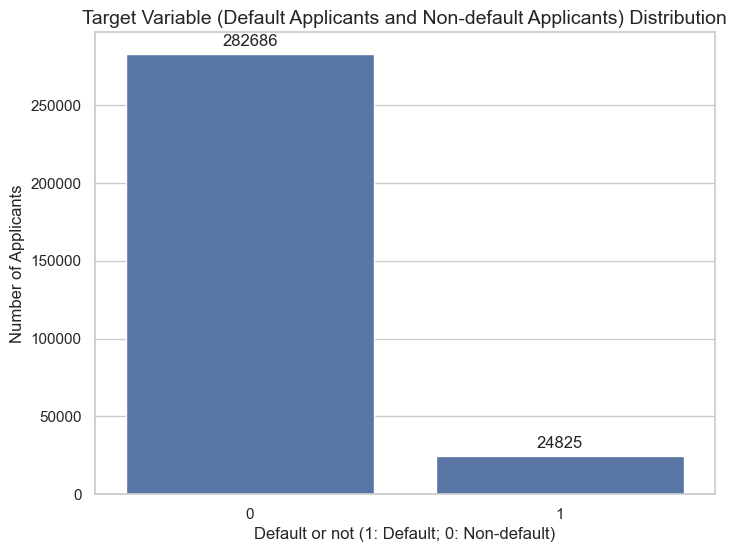

In [16]:
sns.set(style="whitegrid")

plt.figure(figsize=(8, 6))

ax = sns.countplot(x='TARGET', data=df_application)

plt.title('Target Variable (Default Applicants and Non-default Applicants) Distribution', fontsize=14)
plt.xlabel('Default or not (1: Default; 0: Non-default)', fontsize=12)
plt.ylabel('Number of Applicants', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')
plt.show()

In [ ]:
# 使用 random_state=42 保证每次抽样的结果都一样
df_sample = df_application.sample(frac=0.02, random_state=42)

print(f"The 2% data points from the full set -- Sample Shape: {df_sample.shape}")


sample_data_path = '../data/temp_data/sample_application.csv'
df_sample.to_csv(sample_data_path, index=False)
print("\nThe sample data saved")

The 2% data points from the full set -- Sample Shape: (6150, 122)

The sample data saved


### First View of Important Features